### Бизнес-вопрос:
Действительно ли скорость доставки зависит от штата покупателя?

### H0
Среднее/медианное время доставки не отличается между штатами.

### H1
Время доставки статистически значимо отличается между штатами.

#### Импорты

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

True

#### Конфигурация

In [22]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [23]:
connection = create_engine(url=url)

#### Тестирование гипотезы

In [24]:
read_sql_query = ("SELECT EXTRACT (EPOCH FROM (o.order_delivered_customer_date - o.order_purchase_timestamp)) / 86400 as delivery_time_days, c.customer_state "
                  "FROM orders as o "
                  "JOIN customers as c USING(customer_id) "
                  "WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL")

df = pd.read_sql(sql=read_sql_query, con=connection)

##### Базовое описание

In [25]:
df.head()

,delivery_time_days,customer_state
0,8.436574,SP
1,13.782037,BA
2,9.394213,GO
3,13.208750,RN
4,2.873877,SP


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   delivery_time_days  96470 non-null  float64
 1   customer_state      96470 non-null  str    
dtypes: float64(1), str(1)
memory usage: 1.5 MB


In [27]:
df["delivery_time_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64

##### Анализ распределения

In [28]:
state_stats = (
    df.groupby("customer_state")["delivery_time_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
    )
    .sort_values("median")
)
state_stats

,count,mean,median,std
customer_state,,,,
SP,40494,8.761386,7.210272,6.753019
MG,11354,12.008666,10.313513,7.196632
PR,4923,11.991582,10.425509,6.982943
DF,2080,12.967568,11.364925,7.055114
RJ,12350,15.309438,12.041644,11.521916
SC,3546,14.954783,13.014352,8.578273
RS,5344,15.300276,13.177488,9.177480
ES,1995,15.789307,13.636956,10.640684
MS,701,15.618319,13.943796,7.730809


In [29]:
groups = [(i_state, i_df['delivery_time_days'].values) for i_state, i_df in df.groupby("customer_state")]

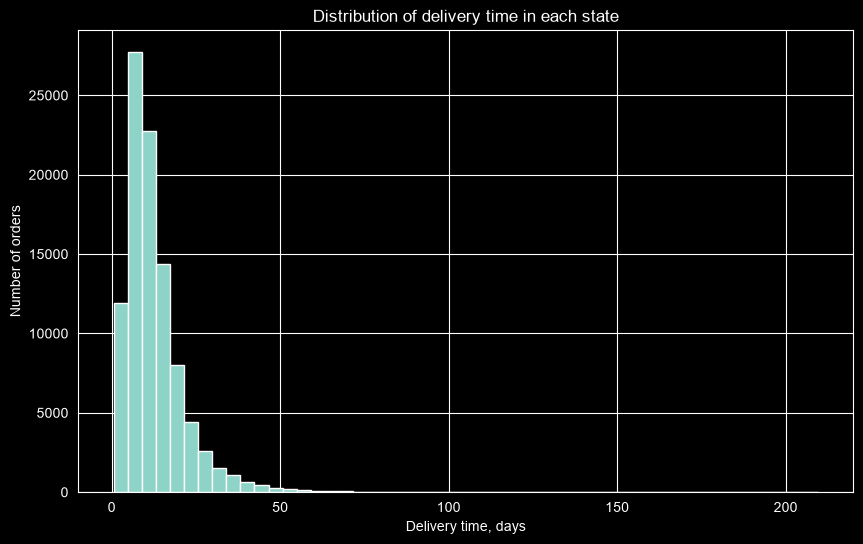

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(df["delivery_time_days"],
    bins=50,
)

plt.title("Distribution of delivery time in each state")
plt.xlabel("Delivery time, days")
plt.ylabel("Number of orders")

plt.show()

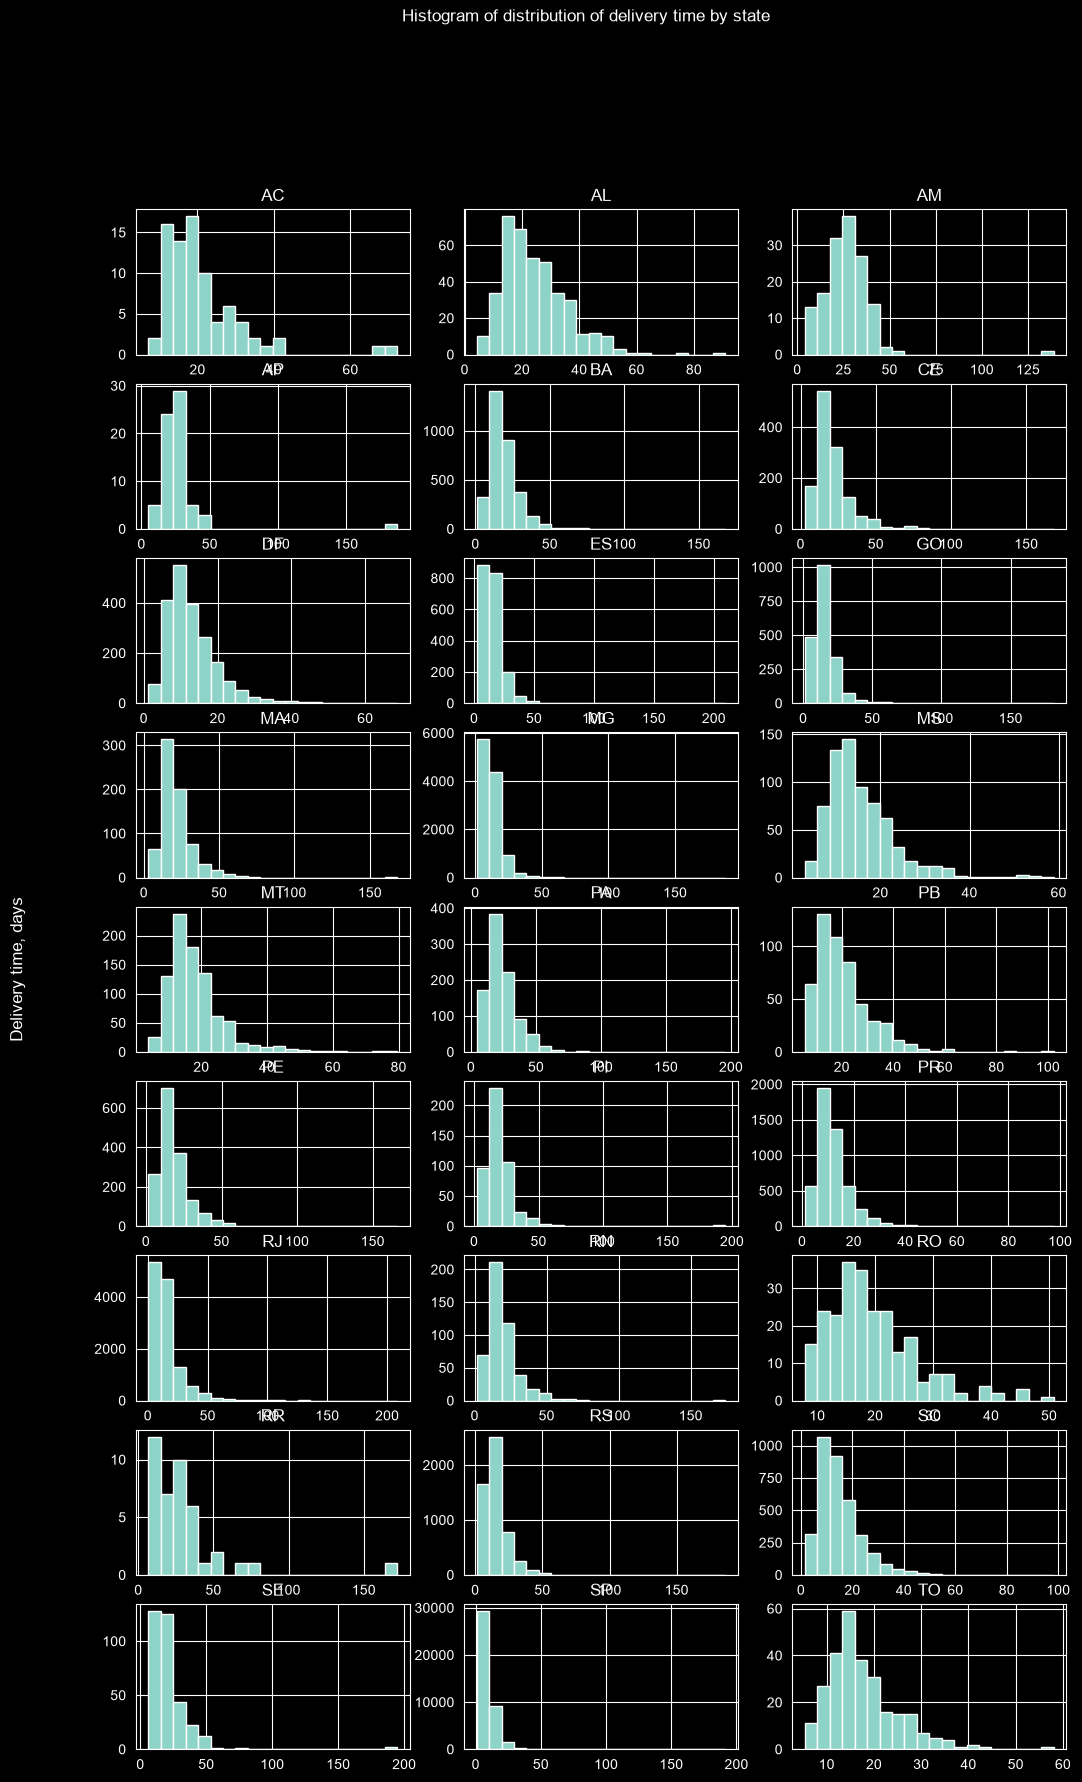

In [31]:
fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(12, 20))

fig.suptitle("Histogram of distribution of delivery time by state")
fig.supylabel('Delivery time, days')

ax_flat = ax.flatten()

for index, i_group in enumerate(groups):
    state = i_group[0]
    delivery_time_days = i_group[1]

    ax_flat[index].hist(delivery_time_days, bins=20)
    ax_flat[index].set_title(state)

plt.show()

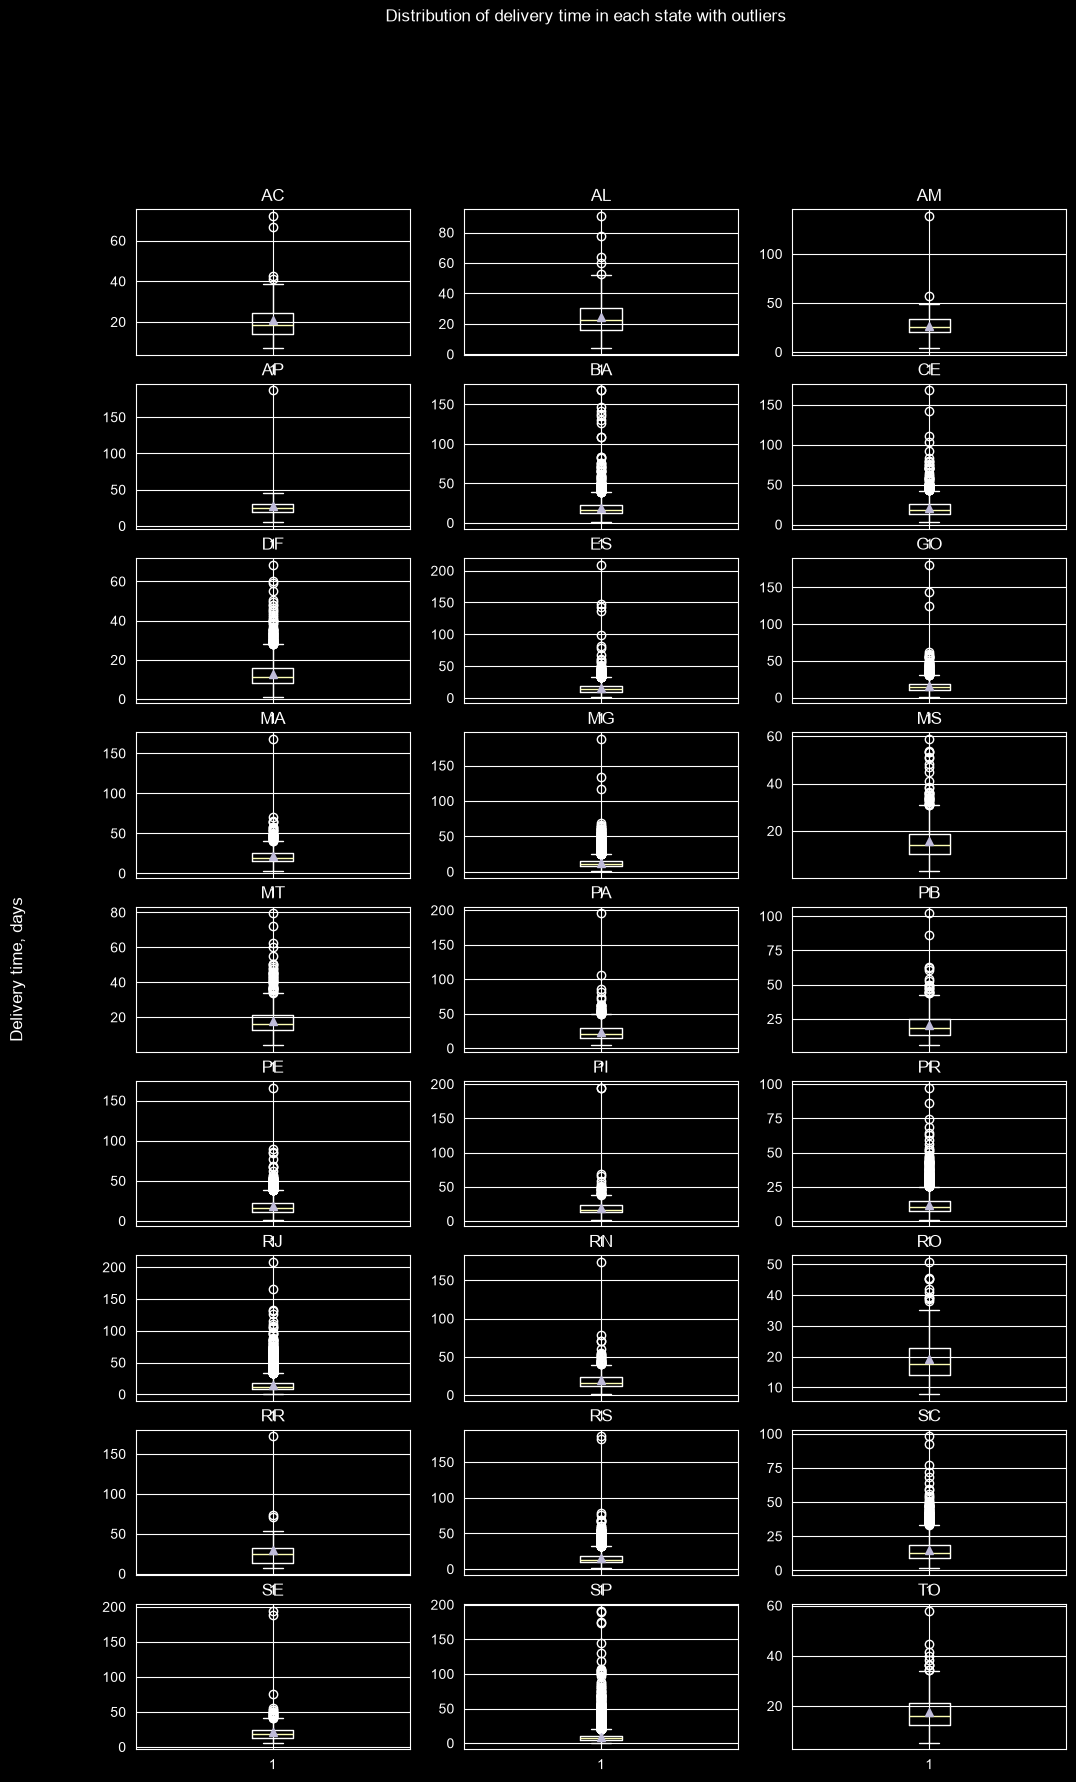

In [32]:
fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(12, 20))

fig.suptitle("Distribution of delivery time in each state with outliers")
fig.supylabel('Delivery time, days')

ax_flat = ax.flatten()

for index, i_group in enumerate(groups):
    state = i_group[0]
    delivery_time_days = i_group[1]

    ax_flat[index].boxplot(delivery_time_days, showfliers=True, showmeans=True)
    ax_flat[index].set_title(state)

plt.show()

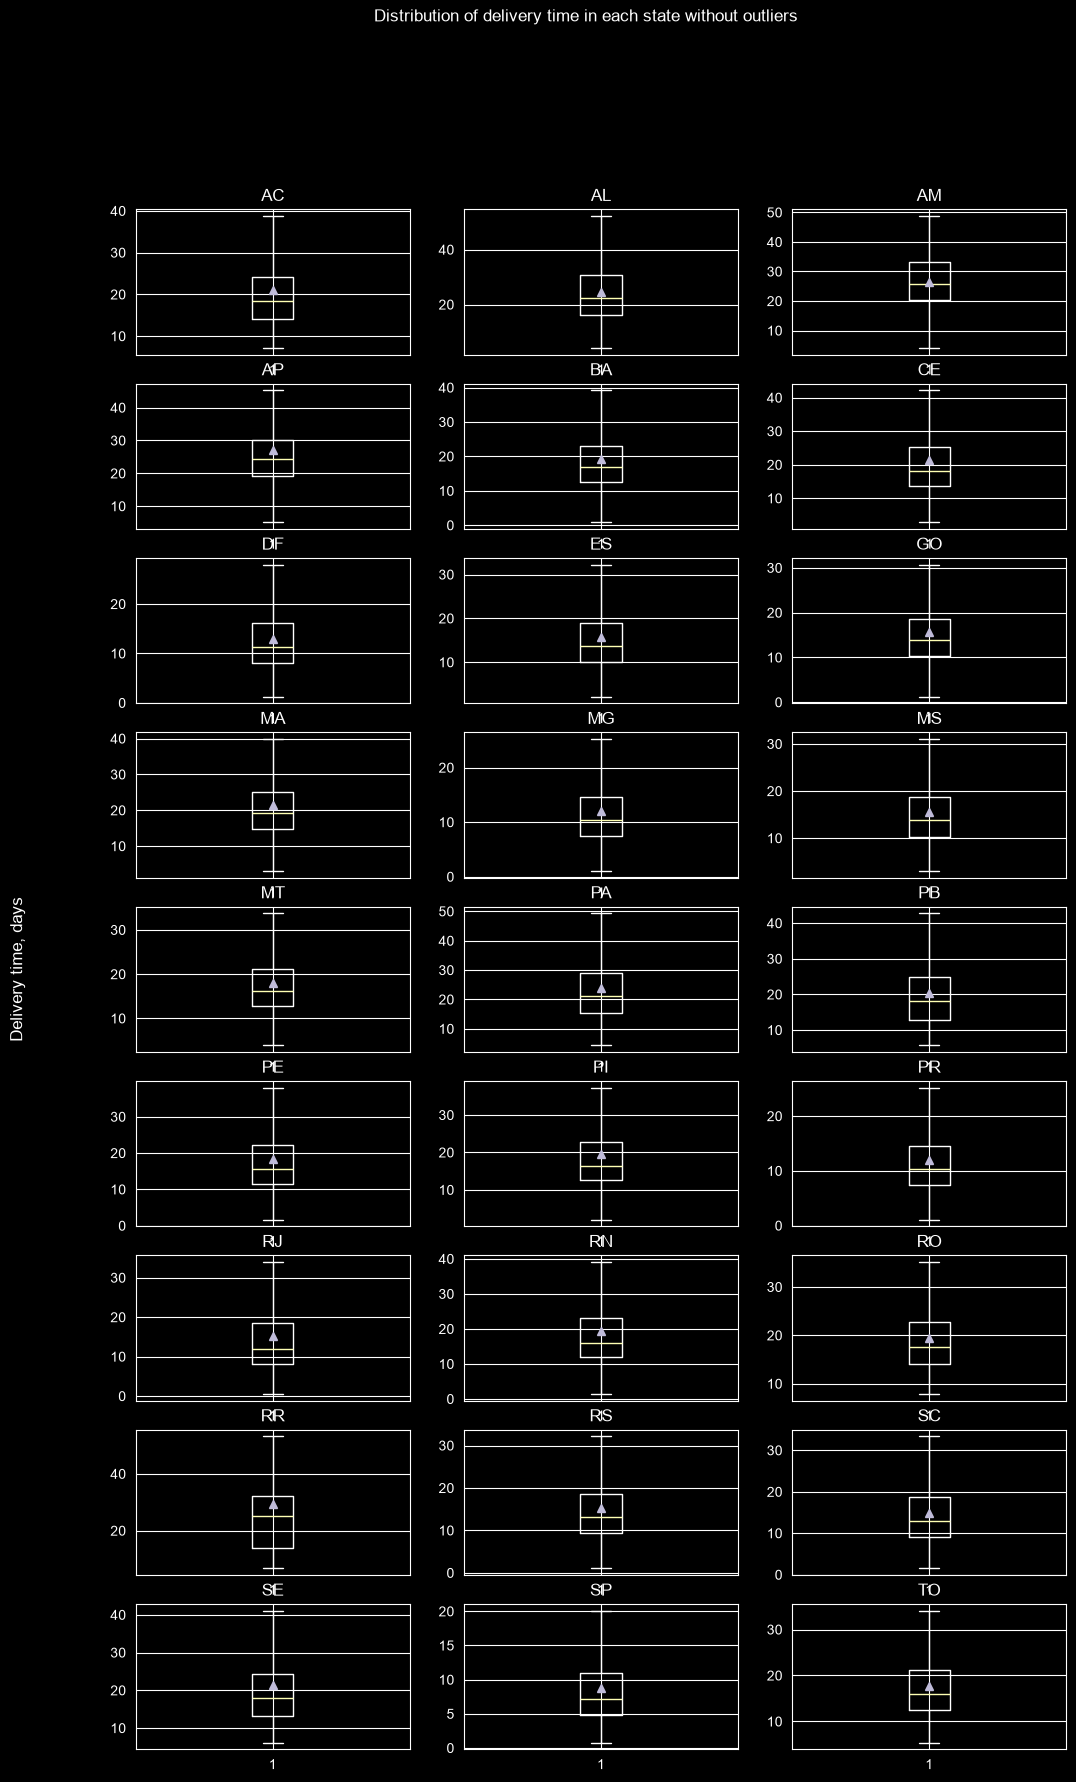

In [33]:
fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(12, 20))

fig.suptitle("Distribution of delivery time in each state without outliers")
fig.supylabel('Delivery time, days')

ax_flat = ax.flatten()

for index, i_group in enumerate(groups):
    state = i_group[0]
    delivery_time_days = i_group[1]

    ax_flat[index].boxplot(delivery_time_days, showfliers=False, showmeans=True)
    ax_flat[index].set_title(state)

plt.show()

In [34]:
results = {'state': [], 'is_normal': [], 'p_value': []}

alpha = 0.05
for state, data in groups:
    _, p_value = stats.shapiro(data)

    results['state'].append(state)
    results['is_normal'].append(p_value >= alpha)
    results['p_value'].append(p_value)
results = pd.DataFrame(results)

print(results)

   state  is_normal        p_value
0     AC      False   7.331160e-10
1     AL      False   1.667213e-13
2     AM      False   2.858579e-14
3     AP      False   7.100526e-15
4     BA      False   1.397511e-58
5     CE      False   3.928886e-40
6     DF      False   1.681504e-38
7     ES      False   1.761871e-54
8     GO      False   4.025035e-51
9     MA      False   4.033036e-30
10    MG      False   3.676397e-80
11    MS      False   6.817072e-24
12    MT      False   1.349750e-28
13    PA      False   1.943132e-32
14    PB      False   1.855059e-21
15    PE      False   7.272706e-41
16    PI      False   9.362882e-34
17    PR      False   2.460939e-58
18    RJ      False   2.615799e-84
19    RN      False   1.528630e-27
20    RO      False   1.385418e-10
21    RR      False   5.801487e-09
22    RS      False   1.115712e-63
23    SC      False   1.158383e-47
24    SE      False   1.033071e-28
25    SP      False  3.108048e-119
26    TO      False   1.447903e-11


C:\Users\-\PycharmProjects\olist_analysis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11354.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\-\PycharmProjects\olist_analysis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12350.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\-\PycharmProjects\olist_analysis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5344.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\-\PycharmProjects\olist_analysis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 40494.
  res = hypotest_fun_out(*samples, *

In [35]:
delivery_times_by_state = [
    data
    for _, data in groups
]

alpha = 0.05
statistic, p_value = stats.kruskal(*delivery_times_by_state)

print(f"Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print("Reject H0")
    print("Delivery time differs significantly between states.")

else:
    print("Fail to reject H0")
    print("There is not enough evidence that delivery time differs between states.")

Statistic: 24168.3077
p-value: 0.000000
Reject H0
Delivery time differs significantly between states.
